# Предварительная обработка текстовых данных (2025)

## Введение

Обработка естественного языка (Natural Language Processing, NLP) — область ИИ, в которой исследуются подходы и инструменты интерпретации (понимания) и генерации естественных языков в виде текста.

Естественный язык — это человеческий язык, который сложился исторически для повседневного общения, а не был специально спроектирован (в отличие от формальных или искусственных языков).

Примеры задач NLP:

* регрессия, классификация и кластеризация текстовых данных
* анализ тональности
* извлечение именованных сущностей
* машинный перевод
* генерация и саммаризация
* тематическое моделирование

Решение любой задачи NLP (в большей или меньшей степени) требует подготовительного этапа — предварительной обработки текстовых данных

Мне нравится делить все задачи NLP на два типа: понимание языка (текст -> ...) и языковое моделирование (... -> текст)

Предварительная обработка — это совокупность методов и техник для подготовки сырых текстовых данных к анализу с применением языковых моделей.

Как и в любой задаче, связанной с ИИ: принцип "garbage in — garbage out"

Конвейер предварительной обработки текстовых данных выглядит следующим образом:

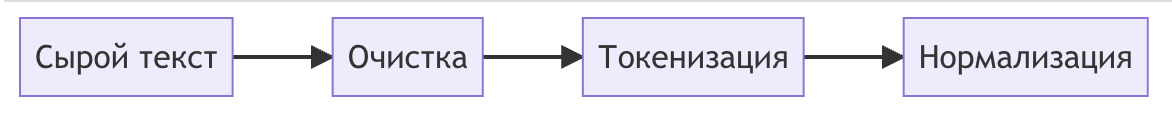

Основные цели предварительной обработки текстовых данных: уменьшение размера признакового пространства и устранение избыточности

Принципы предварительной обработки:

* порядок имеет значение: некоторые операции должны выполняться в определённой последовательности
* контекст задачи учитывается: не все этапы всегда необходимы
* язык текста решает: различные языки требуют разных подходов

## Очистка

### Удаление HTML-тегов

In [ ]:
import re
from bs4 import BeautifulSoup

# Пример текста (можно заменить на чтение из файла)
text = "<p>Привет! Это <b>тестовый</b> текст.</p>"

# 1. Удаляем HTML-теги с помощью регулярных выражений$##№№###ffdfdfdfdf#dfdff#eeeeeeccmddjnc,dnjvnd.kn.dksjddf
text = re.sub(r'<.*?>', '', text)

# 2. Дополнительно извлекаем текст с помощью BeautifulSoup
text = BeautifulSoup(text, "html.parser").get_text()

print(text)

Привет! Это тестовый текст.
Привет! Это тестовый текст.


Регулярные выражения — это язык шаблонов для поиска, проверки и преобразования текста.

### Удаление URL и email

In [ ]:
import re

# Пример текста (можно заменить на чтение из файла)
text = "<p>https\Привет! Это <b>тестовый</b> текст.</p> u@mail.ru"

# Удаление URL
text = re.sub(r'http\S+|www\.\S+', '', text)

print(text)

# Удаление email
text = re.sub(r'\S+@\S+', '', text)

print(text)

<p> Это <b>тестовый</b> текст.</p> u@mail.ru
<p> Это <b>тестовый</b> текст.</p> 


### Удаление знаков препинания

In [9]:
import re

# Пример текста (можно заменить на чтение из файла)
text = "<p>https\Привет! Это <b>тестовый</b> текст.</p> u@mail.ru"

text = re.sub(r'[^\w\s]', '', text)

print(text)

# Оставить только русские буквы и пробельные символы
text = re.sub(r'[^а-яё\s]', '', text, flags=re.IGNORECASE)

print(text)

phttpsПривет Это bтестовыйb текстp umailru
Привет Это тестовый текст 


### Обработка числительных

In [11]:
import re 

# Пример текста (можно заменить на чтение из файла)
text = "<p>https\Привет! Это <b>тестовый</b>343434 текст.</p> u@mail.ruq4q4"

# Полное удаление числительных
text = re.sub(r'\d+', '', text)

print(text)

text = "<p>https\Привет! Это <b>тестовый</b>343434 текст.</p> u@mail.ruq4q4"

# Замена числительных на специальный токен
text = re.sub(r'\d+', 'NUM', text)

print(text)

<p>https\Привет! Это <b>тестовый</b> текст.</p> u@mail.ruqq
<p>https\Привет! Это <b>тестовый</b>NUM текст.</p> u@mail.ruqNUMqNUM


### Обработка пробельных символов

In [17]:
import re 

# Пример текста (можно заменить на чтение из файла)
text = "        <p>https\Привет! Это <b>тестовый</b>343434                текст.</p> u@mail.ruq4q4"

# Удаление лишних пробелов
text = re.sub(r'\s+', ' ', text).strip()

print(text)

text = "        <p>https\Привет! Это <b>тестовый</b>343434                текст.</p> u@mail.ruq4q4"

# Удаление пробелов в начале и конце строк
text = '\n'.join([line.strip() for line in text.split('\n')])

print(text)

<p>https\Привет! Это <b>тестовый</b>343434 текст.</p> u@mail.ruq4q4
<p>https\Привет! Это <b>тестовый</b>343434                текст.</p> u@mail.ruq4q4


**Для очистки текстовых данных также рекомендую использовать библиотеки clean-text и emoji**

## Токенизация

Токенизацией называется разделение текстового документа на неделимые единицы (токены). В качестве токенов в NLP могут выступать:

* предложения
* слова
* части слов (subword tokenization)
* символы


### Слова и предложения

Самый простой пример токенизации:

In [18]:
text = "Токенизация - это просто!"
tokens = text.split()
print(tokens)

['Токенизация', '-', 'это', 'просто!']


Токенизация на основе правил (с применением nltk)

In [29]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/macbook/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [30]:
from nltk.tokenize import word_tokenize, sent_tokenize

text = "Hello! How are you doing today? I hope everything is going well. "

tokens = word_tokenize(text)
sentences = sent_tokenize(text)

print(tokens)
print(sentences)

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/Users/macbook/nltk_data'
    - '/Users/macbook/Desktop/NLP/nlp_labs/nltk_data'
    - '/Users/macbook/Desktop/NLP/nlp_labs/share/nltk_data'
    - '/Users/macbook/Desktop/NLP/nlp_labs/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [31]:
from nltk.tokenize import ToktokTokenizer

tokenizer = ToktokTokenizer()

text = "Hello! How are you doing today? I hope everything is going well."

tokens = tokenizer.tokenize(text)
print(tokens)

['Hello', '!', 'How', 'are', 'you', 'doing', 'today', '?', 'I', 'hope', 'everything', 'is', 'going', 'well', '.']


Применение регулярных выражений (не рекомендуется при решении прикладных задач):

In [32]:
import re

text = "Я люблю AI, ML и NLP!"
tokens = re.findall(r'\b\w+\b', text)
print(tokens)

['Я', 'люблю', 'AI', 'ML', 'и', 'NLP']


При токенизации текстов на русском языке на уровне слов рекомендуется применять библиотеку razdel, которая является частью проекта Natasha. Он запущен в 2020 году Лабораторией анализа данных Александра Кукушкина.

Также можно использовать мультиязычные фреймворки-конвейеры Spacy и Stanza.

Для определения языка текста можно использовать это [решение](https://github.com/pemistahl/lingua-py).

Забегая немного вперёд, важно сказать, что токены впоследствие будут ассоциироваться с числами и векторами.

Токенизация на уровне слов подвержена проблеме Out of Vocabulary (OOV) и приводит к большим объёмам словарей. В то же время токенизация на уровне символов дает возможность работать с небольшими словарями, однако в задачах, связанных с языковым моделированием, при векторизации символа (даже с учетом информации о позиции), сохраняется меньше деталей, чем при векторизации на уровне слов.

### Subword-токенизация

Современным подходом к токенизации является токенизация на уровне частей слов. Актуальные подходы:

* Byte Pair Encoding (BPE): используется в моделях OpenAI и в фирменном токенизаторе tiktoken
* WordPiece: используются Google в моделях на основе BERT

#### Пример обучения и работы BPE

Пусть есть небольшой обучающий корпус (так в NLP называют наборы текстовых данных), состоящий всего из одной фразы (одного текстового документа), где некоторые слова повторяются или имеют общие корни:

**старый читатель перечитал старые книги**

Считаем частоту каждого слова и разбиваем все слова на последовательности символов. Чтобы отличать конец слова добавляем специальный маркер < /w >.

In [33]:
'''
старый (1 раз) -> с т а р ы й </w>
читатель (1 раз) -> ч и т а т е л ь </w>
перечитал (1 раз) -> п е р е ч и т а л </w>
старые (1 раз) -> с т а р ы е </w>
книги (1 раз) -> к н и г и </w>
'''

'\nстарый (1 раз) -> с т а р ы й </w>\nчитатель (1 раз) -> ч и т а т е л ь </w>\nперечитал (1 раз) -> п е р е ч и т а л </w>\nстарые (1 раз) -> с т а р ы е </w>\nкниги (1 раз) -> к н и г и </w>\n'

Начальный словарь токенов состоит из символов: {с, т, а, р, ы, й, ч, и, е, л, ь, п, к, н, г, < /w >}.

##### Слияние 1:

Подсчитаем все пары токенов. Необходимо выбрать наиболее часто встречающуюся. Пара (с, т) встречается 4 раза (в старый и старые). Пара (т, а) — 2 раза (читатель, перечитал). Пара (ч, и) — 2 раза. Выбираем (с, т) (для примера). Объединяем с и т в новый токен ст. Результат:

In [34]:
'''
ст а р ы й </w>
ч и т а т е л ь </w>
п е р е ч и т а л </w>
ст а р ы е </w>
к н и г и </w>
'''

'\nст а р ы й </w>\nч и т а т е л ь </w>\nп е р е ч и т а л </w>\nст а р ы е </w>\nк н и г и </w>\n'

Процесс повторяется заданное количество раз (количество слияний — гиперпараметр). Получим словарь (с, т, ..., ст, ар, чи, стар, ...) и список правил слияния. Токенизация слова старость будет:

["стар", "о", "с", "т", "ь", "< /w >"]

**Важный вывод: мы наблюдаем процесс обучения токенизатора**

Можно использовать библиотеку tokenizers (пример обучения токенизатора на своих данных):

In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import BPE

tokenizer = Tokenizer(BPE())
tokenizer.train(files=["corpus.txt"])

encoded = tokenizer.encode("машинное обучение")

WordPiece (также реализован в библиотеке tokenizers) отличается правилом выбора пары токенов для объединения. Для каждой пары вычисляется оценка выгоды от объединения по формуле:

оценка = частота(AB) / (частота(A) * частота(B))

## Нормализация

### Удаление стоп-слов

Стоп-слова — часто встречающиеся слова, которые несут мало смысловой информации: "в", "и", "на", "с", "по" и т.д.

В общем случае стоп-слова определяются индивидуально для каждой задачи, однако следующие вещи принято всегда относить к стоп-словам:

* знаки препинания и специальные символы
* предлоги, союзы
* часто употребляемые слова в языке
* артикли

Удаление стоп-слов с применением NLTK:

In [37]:
from nltk.corpus import stopwords

nltk.download('stopwords')
russian_stopwords = set(stopwords.words('russian'))

filtered_tokens = [word for word in tokens if word not in russian_stopwords]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/macbook/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**При работе с мультиязычными текстами не забывайте удалять стоп-слова из других языков**

Расширение списка стоп-слов:

In [38]:
custom_stopwords = russian_stopwords.union({
    'это', 'который', 'может', 'один', 'два'
})

domain_stopwords = {'компания', 'организация', 'система'}

### Стемминг и лемматизация

Слова в естественных языках часто употребляются в различных видах и формах, при этом семантика слова не изменяется (слова 'красивый', 'красивая', 'красивое' с точки зрения семантики одинаковы). Нормализация данных предполагает, что все семантически одинаковые слова мы заменяем одним словом — нормальной формой. Существует два подхода к нормализации:

* стемминг (определение основы слова)
* лемматизация (определение начальной формы на основе словаря)

Пример стемминга:

In [ ]:
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer('russian')
stemmed_words = [stemmer.stem(word) for word in tokens]

# "программирование" - "программирован"
# "программист" - "программист"
# "программы" - "программ"

Пример лемматизации с использованием библиотеки pymorphy3:

In [ ]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

lemmatized_words = [lemmatize_word(word) for word in tokens]

Библиотека использует данные из открытого корпуса для русского языка OpenCorpora:

In [ ]:
morph.tag('красивая')
# [OpencorporaTag('ADJF,Qual femn,sing,nomn')]

Более подробно ознакомиться с информацией о тегах можно в [документации](https://pymorphy2.readthedocs.io/en/stable/).